<a href="https://colab.research.google.com/github/Elenadr/evaluaciondelmodelo/blob/main/An%C3%A1lisis_de_Falsos_Positivos_y_Tolerancia_al_Ruido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Preparación del Conjunto de Prueba
Vamos a generar 40 archivos (10 SubGHz seguros, 10 SubGHz vulnerables, 10 NFC seguros, 10 NFC vulnerables) y guardarlos en tu Google Drive. Usaremos un script para generar estos archivos sintéticos, similar a generate_synthetic_nfc_files, pero adaptado para este experimento.

In [5]:
# -*- coding: utf-8 -*-
import os
import random
import re
from google.colab import drive

# Montar Google Drive
drive.mount('/content/drive')

# Directorio para guardar los archivos de prueba
test_dir = "/content/drive/MyDrive/EvalModelNFC/test_files"
if not os.path.exists(test_dir):
    os.makedirs(test_dir)

# Definir claves por defecto
default_keys = {
    "FF FF FF FF FF FF",
    "A0 A1 A2 A3 A4 A5",
    "D3 F7 D3 F7 D3 F7",
    "00 00 00 00 00 00",
    "B0 B1 B2 B3 B4 B5",
    "4D 3A 99 C3 51 DD"
}

# Función para generar un UID aleatorio
def generate_random_uid():
    return " ".join([f"{random.randint(0, 255):02X}" for _ in range(4)])

# Función para generar archivos SubGHz
def generate_subghz_files(num_files, secure=True, dir_path=test_dir):
    files = []
    for i in range(num_files):
        if secure:
            # Archivo SubGHz seguro
            frequency = random.choice([868350000, 915000000])  # Frecuencias seguras
            preset = "FuriHalSubGhzPresetAES"
            protocol = random.choice(["AES-Encrypted", "KeeLoq-Secure"])
            key = " ".join([f"{random.randint(0, 255):02X}" for _ in range(8)])  # Clave única
            content = [
                "Filetype: Flipper Sub-GHz Key File",
                "Version: 1",
                f"Frequency: {frequency}",
                f"Preset: {preset}",
                f"Protocol: {protocol}",
                f"Key: {key}"
            ]
            file_name = f"sub_secure_{i+1}.sub"
        else:
            # Archivo SubGHz vulnerable
            frequency = random.choice([433920000, 315000000])  # Frecuencias inseguras
            preset = random.choice(["FuriHalSubGhzPresetOok650Async", "FuriHalSubGhzPresetOok270Async"])
            protocol = "OOK"
            key = "AA AA AA AA AA AA AA AA"  # Patrón repetitivo (Código Fijo)
            raw_data = "RAW_Data: 500 -500 500 -500 " * 5  # Datos repetitivos (Código Fijo)
            content = [
                "Filetype: Flipper Sub-GHz Key File",
                "Version: 1",
                f"Frequency: {frequency}",
                f"Preset: {preset}",
                f"Protocol: {protocol}",
                f"Key: {key}",
                raw_data
            ]
            file_name = f"sub_vulnerable_{i+1}.sub"

        file_path = os.path.join(dir_path, file_name)
        with open(file_path, 'w') as f:
            f.write("\n".join(content))
        files.append(file_path)
    return files

# Función para generar archivos NFC
def generate_nfc_files(num_files, secure=True, dir_path=test_dir):
    files = []
    for i in range(num_files):
        if secure:
            # Archivo NFC seguro (MIFARE DESFire)
            content = [
                "Filetype: Flipper NFC device",
                "Version: 4",
                "Device type: MIFARE DESFire",
                f"UID: {generate_random_uid()}",
                "ATQA: 03 44",
                "SAK: 20",
                "Protocol: AES-Encrypted",
                "Data format version: 2"
            ]
            file_name = f"nfc_secure_{i+1}.nfc"
        else:
            # Archivo NFC vulnerable (MIFARE Classic)
            blocks = [f"Block {j}: {' '.join([random.choice(list(default_keys)) for _ in range(4)])}" for j in range(10)]
            content = [
                "Filetype: Flipper NFC device",
                "Version: 4",
                "Device type: MIFARE Classic",
                f"UID: {generate_random_uid()}",
                "ATQA: 00 04",
                "SAK: 08",
            ] + blocks
            file_name = f"nfc_vulnerable_{i+1}.nfc"

        file_path = os.path.join(dir_path, file_name)
        with open(file_path, 'w') as f:
            f.write("\n".join(content))
        files.append(file_path)
    return files

# Generar archivos de prueba
sub_secure_files = generate_subghz_files(10, secure=True)
sub_vulnerable_files = generate_subghz_files(10, secure=False)
nfc_secure_files = generate_nfc_files(10, secure=True)
nfc_vulnerable_files = generate_nfc_files(10, secure=False)

# Mostrar los archivos generados
print("Archivos SubGHz Seguros:", sub_secure_files)
print("Archivos SubGHz Vulnerables:", sub_vulnerable_files)
print("Archivos NFC Seguros:", nfc_secure_files)
print("Archivos NFC Vulnerables:", nfc_vulnerable_files)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archivos SubGHz Seguros: ['/content/drive/MyDrive/EvalModelNFC/test_files/sub_secure_1.sub', '/content/drive/MyDrive/EvalModelNFC/test_files/sub_secure_2.sub', '/content/drive/MyDrive/EvalModelNFC/test_files/sub_secure_3.sub', '/content/drive/MyDrive/EvalModelNFC/test_files/sub_secure_4.sub', '/content/drive/MyDrive/EvalModelNFC/test_files/sub_secure_5.sub', '/content/drive/MyDrive/EvalModelNFC/test_files/sub_secure_6.sub', '/content/drive/MyDrive/EvalModelNFC/test_files/sub_secure_7.sub', '/content/drive/MyDrive/EvalModelNFC/test_files/sub_secure_8.sub', '/content/drive/MyDrive/EvalModelNFC/test_files/sub_secure_9.sub', '/content/drive/MyDrive/EvalModelNFC/test_files/sub_secure_10.sub']
Archivos SubGHz Vulnerables: ['/content/drive/MyDrive/EvalModelNFC/test_files/sub_vulnerable_1.sub', '/content/drive/MyDrive/EvalModelNFC/test_files/sub_vulnerable_2.sub', '/

## Etiquetado Manual (Ground Truth)

Vamos a etiquetar manualmente cada archivo usando las funciones label_sub_file y label_nfc_file para establecer la verdad absoluta. A continuación, añadimos estas funciones al script y generamos las etiquetas.

In [6]:
# Definir claves por defecto
default_keys = {
    "FF FF FF FF FF FF",
    "A0 A1 A2 A3 A4 A5",
    "D3 F7 D3 F7 D3 F7",
    "00 00 00 00 00 00",
    "B0 B1 B2 B3 B4 B5",
    "4D 3A 99 C3 51 DD"
}

# Función para etiquetar archivos SubGHz
def label_sub_file(content, debug=False):
    lines = content.split('\n')
    vulnerabilities = []
    frecuencia_hz = None
    preset = ""
    protocolo = ""
    key = ""
    has_raw_data = any("RAW_Data" in line for line in lines)

    for line in lines:
        if line.startswith("Frequency:"):
            try:
                frecuencia_hz = int(line.split(":")[1].strip())
            except ValueError:
                frecuencia_hz = None
        elif line.startswith("Preset:"):
            preset = line.split(":")[1].strip()
        elif line.startswith("Protocol:"):
            protocolo = line.split(":")[1].strip()
        elif line.startswith("Key:"):
            key = line.split(":", 1)[1].strip()

    if debug:
        print(f"Debug: Frequency={frecuencia_hz}, Preset={preset}, Protocol={protocolo}, Key={key}, Has RAW={has_raw_data}")

    secure_frequencies = [868350000, 915000000]
    secure_presets = ["FuriHalSubGhzPresetAES"]
    secure_protocols = ["AES-Encrypted", "KeeLoq", "KeeLoq-Secure"]
    prob_rolling_code = 0.0
    prob_codigo_fijo = 0.0

    if frecuencia_hz in [433920000, 315000000]:
        vulnerabilities.append("Frecuencia Insegura")
        prob_codigo_fijo += 0.3
        if debug:
            print("Debug: Added Frecuencia Insegura")

    insecure_protocols = ["OOK", "RAW"]
    if any(p.lower() in protocolo.lower() for p in insecure_protocols) and protocolo not in secure_protocols:
        vulnerabilities.append("Sin Cifrado")
        prob_codigo_fijo += 0.3
        if debug:
            print("Debug: Added Sin Cifrado")

    insecure_presets = ["FuriHalSubGhzPresetOok650Async", "FuriHalSubGhzPresetOok270Async"]
    if preset in insecure_presets:
        vulnerabilities.append("Modulación Insegura")
        prob_codigo_fijo += 0.3
        if debug:
            print("Debug: Added Modulación Insegura")

    if has_raw_data:
        raw_lines = [line for line in lines if "RAW_Data" in line]
        raws = [re.findall(r"[-\d]+", line) for line in raw_lines]
        if len(raws) >= 2:
            repetition_count = sum(1 for i in range(len(raws)-1) if raws[i] == raws[i+1])
            if repetition_count >= len(raws) * 0.5:
                prob_codigo_fijo = max(prob_codigo_fijo, 1.0)
                if debug:
                    print("Debug: High repetition in RAW_Data, setting prob_codigo_fijo=1.0")
            elif len(raw_lines) > 10 and repetition_count == 0:
                prob_rolling_code = 0.7
                if debug:
                    print("Debug: Long non-repeating RAW_Data, setting prob_rolling_code=0.7")
    else:
        if protocolo in ["KeeLoq", "KeeLoq-Secure"]:
            prob_rolling_code = 0.9
            if debug:
                print("Debug: KeeLoq protocol, setting prob_rolling_code=0.9")
        else:
            key_parts = key.split()
            if len(key_parts) > 4 and len(set(key_parts)) < len(key_parts) / 2:
                prob_codigo_fijo = max(prob_codigo_fijo, 0.8)
                if debug:
                    print("Debug: Repetitive key pattern, setting prob_codigo_fijo=0.8")

    if prob_codigo_fijo >= 0.8:
        vulnerabilities.append("Código Fijo")
        if debug:
            print("Debug: Added Código Fijo")

    if (not vulnerabilities and
        frecuencia_hz in secure_frequencies and
        preset in secure_presets and
        protocolo in secure_protocols and
        not has_raw_data):
        vulnerabilities = ["Segura"]
        if debug:
            print("Debug: No vulnerabilities and secure configuration, labeling as Segura")
    else:
        if prob_rolling_code >= 0.8 and debug:
            print("Debug: High prob_rolling_code but vulnerabilities present, keeping vulnerabilities")
        prob_rolling_code = min(prob_rolling_code, 0.2) if vulnerabilities else prob_rolling_code
        if debug:
            print("Debug: Vulnerabilities detected, adjusting prob_rolling_code")

    if debug:
        print(f"Debug: Final vulnerabilities={vulnerabilities}, Prob Rolling Code={prob_rolling_code}")

    return vulnerabilities, prob_rolling_code

# Función para etiquetar archivos NFC
def label_nfc_file(content, debug=False):
    lines = content.split('\n')
    vulnerable_uid = False
    bloques_leidos = 0
    claves_encontradas = set()
    tipo = None
    pages_read = 0
    pages_total = 0
    has_password = False
    counter_0 = 0
    counter_1 = 0
    counter_2 = 0

    for line in lines:
        if line.startswith("Device type:") or line.startswith("Type:"):
            tipo = line.strip().split(":", 1)[1].strip()
        elif re.search(r'Block \d+:', line) and "MIFARE Classic" in tipo:
            bloques_leidos += 1
            data = line.split(':', 1)[1].strip().upper()
            if any(key in data for key in default_keys):
                claves_encontradas.add(data)
        elif re.search(r'Key [AB]:', line) and "MIFARE Classic" in tipo:
            key = line.split(':', 1)[1].strip().upper()
            if any(key in dk for dk in default_keys):
                claves_encontradas.add(key)
        elif line.startswith("Pages total:"):
            pages_total = int(line.split(":")[1].strip())
        elif line.startswith("Pages read:"):
            pages_read = int(line.split(":")[1].strip())
        elif "Password:" in line or "PACK:" in line:
            has_password = True
        elif line.startswith("Counter 0:"):
            counter_0 = int(line.split(":")[1].strip())
        elif line.startswith("Counter 1:"):
            counter_1 = int(line.split(":")[1].strip())
        elif line.startswith("Counter 2:"):
            counter_2 = int(line.split(":")[1].strip())

    if debug:
        print(f"Debug: Type={tipo}, Bloques leídos={bloques_leidos}, Claves encontradas={claves_encontradas}, Pages read={pages_read}/{pages_total}, Has password={has_password}, Counters={counter_0},{counter_1},{counter_2}")

    vulnerabilidades = []
    if "MIFARE Classic" in tipo:
        vulnerable_uid = True
        if claves_encontradas:
            vulnerabilidades.append("Claves por defecto")
        if bloques_leidos >= 8:
            vulnerabilidades.append("Lectura completa")
        if claves_encontradas and bloques_leidos > 0:
            vulnerabilidades.append("Escritura posible")
    elif "NTAG" in tipo:
        if pages_read >= pages_total and pages_total > 0:
            vulnerabilidades.append("Lectura completa")
            if not has_password and (counter_0 > 0 or counter_1 > 0 or counter_2 > 0):
                vulnerabilidades.append("Escritura posible")
        vulnerable_uid = False
    else:
        vulnerable_uid = False

    if vulnerable_uid:
        vulnerabilidades.append("UID clonable")

    if not vulnerabilidades:
        vulnerabilidades = ["No detectada"]

    if debug:
        print(f"Debug: Vulnerabilidades={vulnerabilidades}")

    return vulnerabilidades

# Etiquetar los archivos generados
ground_truth = {}

# Etiquetar archivos SubGHz
for file_path in sub_secure_files + sub_vulnerable_files:
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read().strip()
    labels, _ = label_sub_file(content, debug=True)
    ground_truth[file_path] = labels

# Etiquetar archivos NFC
for file_path in nfc_secure_files + nfc_vulnerable_files:
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read().strip()
    labels = label_nfc_file(content, debug=True)
    ground_truth[file_path] = labels

# Mostrar las etiquetas ground truth
print("\nGround Truth (Etiquetas Verdaderas):")
for file_path, labels in ground_truth.items():
    print(f"{file_path}: {labels}")

Debug: Frequency=868350000, Preset=FuriHalSubGhzPresetAES, Protocol=KeeLoq-Secure, Key=C6 C4 D7 FF BA C3 BC 0B, Has RAW=False
Debug: KeeLoq protocol, setting prob_rolling_code=0.9
Debug: No vulnerabilities and secure configuration, labeling as Segura
Debug: Final vulnerabilities=['Segura'], Prob Rolling Code=0.9
Debug: Frequency=915000000, Preset=FuriHalSubGhzPresetAES, Protocol=AES-Encrypted, Key=5C AF 8A 80 7E E6 34 9C, Has RAW=False
Debug: No vulnerabilities and secure configuration, labeling as Segura
Debug: Final vulnerabilities=['Segura'], Prob Rolling Code=0.0
Debug: Frequency=915000000, Preset=FuriHalSubGhzPresetAES, Protocol=AES-Encrypted, Key=32 EB 96 0B 0F B6 82 75, Has RAW=False
Debug: No vulnerabilities and secure configuration, labeling as Segura
Debug: Final vulnerabilities=['Segura'], Prob Rolling Code=0.0
Debug: Frequency=915000000, Preset=FuriHalSubGhzPresetAES, Protocol=KeeLoq-Secure, Key=29 4C 15 AF E8 C5 D3 FC, Has RAW=False
Debug: KeeLoq protocol, setting prob_rol

## Cuantificación de Falsos Positivos
Ahora ejecutaremos predict_vulnerabilities en cada archivo y calcularemos la tasa de falsos positivos para las señales seguras.

In [7]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification

# Cargar modelos y tokenizer
tokenizer = BertTokenizer.from_pretrained('/content/drive/MyDrive/models/tokenizer')
sub_model = BertForSequenceClassification.from_pretrained('/content/drive/MyDrive/models/sub_model')
nfc_model = BertForSequenceClassification.from_pretrained('/content/drive/MyDrive/models/nfc_model')

# Definir clases
sub_classes = ["Frecuencia Insegura", "Sin Cifrado", "Modulación Insegura", "Código Fijo", "Segura"]
nfc_classes = ["Claves por defecto", "Lectura completa", "Escritura posible", "UID clonable", "No detectada"]

# Función de predicción
def predict_vulnerabilities(file_path, threshold=0.5):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            content = f.read().strip()
    except UnicodeDecodeError:
        with open(file_path, 'r', encoding='latin-1') as f:
            content = f.read().strip()
    except Exception as e:
        print(f"Error al leer {file_path}: {str(e)}")
        return ["Error al procesar el archivo"]

    model = sub_model if file_path.endswith('.sub') else nfc_model
    classes = sub_classes if file_path.endswith('.sub') else nfc_classes

    # Extraer atributos
    frecuencia_hz = None
    preset = ""
    protocolo = ""
    tipo = ""
    has_raw_data = "RAW_Data" in content
    has_password = "Password:" in content or "PACK:" in content
    bloques_leidos = len([line for line in content.split('\n') if re.search(r'Block \d+:', line)])
    claves_encontradas = any(key in content.upper() for key in default_keys)
    pages_read = 0
    pages_total = 0

    for line in content.split('\n'):
        if line.startswith("Frequency:"):
            try:
                frecuencia_hz = int(line.split(":")[1].strip())
            except ValueError:
                frecuencia_hz = None
        elif line.startswith("Preset:"):
            preset = line.split(":")[1].strip()
        elif line.startswith("Protocol:"):
            protocolo = line.split(":")[1].strip()
        elif line.startswith("Device type:") or line.startswith("Type:"):
            tipo = line.strip().split(":", 1)[1].strip()
        elif line.startswith("Pages total:"):
            pages_total = int(line.split(":")[1].strip())
        elif line.startswith("Pages read:"):
            pages_read = int(line.split(":")[1].strip())

    extra_features = f"Bloques leidos: {bloques_leidos} Claves encontradas: {claves_encontradas} Tipo: {tipo}"
    content_with_features = content + "\n" + extra_features

    encodings = tokenizer(content_with_features, padding=True, truncation=True, max_length=512, return_tensors='pt')
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    encodings = {key: val.to(device) for key, val in encodings.items()}
    model.to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(**encodings)
        logits = outputs.logits
        probs = torch.sigmoid(logits).cpu().numpy()[0]

    print(f"\nProbabilidades para {file_path}:")
    for cls, prob in zip(classes, probs):
        print(f"{cls}: {prob:.4f}")

    predicted_vulns = [classes[i] for i, prob in enumerate(probs) if prob > threshold]

    # Reglas basadas en características extraídas para NFC
    if file_path.endswith('.nfc'):
        if claves_encontradas and "Claves por defecto" not in predicted_vulns:
            predicted_vulns.append("Claves por defecto")
        if bloques_leidos >= 8 and "Lectura completa" not in predicted_vulns:
            predicted_vulns.append("Lectura completa")
        if "MIFARE Classic" in tipo and "UID clonable" not in predicted_vulns:
            predicted_vulns.append("UID clonable")
        if "MIFARE DESFire" in tipo and "UID clonable" in predicted_vulns:
            predicted_vulns.remove("UID clonable")
        if bloques_leidos == 0 and pages_read == 0:
            if "Lectura completa" in predicted_vulns:
                predicted_vulns.remove("Lectura completa")
            if "Escritura posible" in predicted_vulns:
                predicted_vulns.remove("Escritura posible")

    final_vulns = predicted_vulns.copy()
    if file_path.endswith('.sub'):
        if any(v in final_vulns for v in ["Frecuencia Insegura", "Sin Cifrado", "Modulación Insegura", "Código Fijo"]):
            if "Segura" in final_vulns:
                final_vulns.remove("Segura")
    else:
        if any(v in final_vulns for v in ["Claves por defecto", "Lectura completa", "Escritura posible", "UID clonable"]):
            if "No detectada" in final_vulns:
                final_vulns.remove("No detectada")

    if not final_vulns:
        final_vulns = ["Ninguna vulnerabilidad detectada"]

    print("\n" + "="*50)
    print(f"📄 Análisis de: {file_path}")
    print("="*50)
    print("\n🚨 Vulnerabilidades detectadas:")
    print("-"*40)
    for vuln in final_vulns:
        print(f"• {vuln}")
    if file_path.endswith('.sub'):
        _, prob_rolling_code = label_sub_file(content, debug=True)
        print(f"• Probabilidad de Código Variable: {prob_rolling_code:.2f}")
    print("-"*40)

    if final_vulns != ["Ninguna vulnerabilidad detectada"]:
        print("\n💥 Métodos de explotación sugeridos:")
        print("-"*40)
        if file_path.endswith('.sub'):
            for vuln in final_vulns:
                if vuln == "Frecuencia Insegura":
                    print(f"🔧 {vuln}:")
                    print(f"   Frecuencia: {frecuencia_hz} Hz")
                    print("   Explotación: Capturar y retransmitir la señal para un ataque de repetición.")
                    print("   Herramientas: Flipper Zero, HackRF One, Yard Stick One")
                elif vuln == "Sin Cifrado":
                    print(f"🔧 {vuln}:")
                    print(f"   Protocolo: {protocolo}")
                    print("   Explotación: Interceptar y decodificar datos en texto plano.")
                    print("   Herramientas: URH, Flipper Zero, RTL-SDR")
                elif vuln == "Modulación Insegura":
                    print(f"🔧 {vuln}:")
                    print(f"   Preset: {preset}")
                    print("   Explotación: Jamming o suplantación de señal debido a modulación predecible.")
                    print("   Herramientas: Flipper Zero, HackRF One")
                elif vuln == "Código Fijo":
                    print(f"🔧 {vuln}:")
                    print("   Explotación: Clonar código fijo capturando y retransmitiéndolo.")
                    print("   Herramientas: Flipper Zero, Proxmark3, SDR")
                elif vuln == "Segura":
                    print(f"🔧 {vuln}:")
                    print("   Nota: Protocolo seguro detectado. Verificar implementación del receptor.")
        else:
            for vuln in final_vulns:
                if vuln == "Claves por defecto":
                    print(f"🔧 {vuln}:")
                    print(f"   Tipo: {tipo}")
                    print("   Explotación: Usar claves por defecto para acceder a datos o modificar tarjeta.")
                    print("   Herramientas: Proxmark3, NFC Tools")
                elif vuln == "Lectura completa":
                    print(f"🔧 {vuln}:")
                    print(f"   Bloques leídos: {bloques_leidos}")
                    print("   Explotación: Extraer todos los datos de la tarjeta para análisis o clonación.")
                    print("   Herramientas: Proxmark3, NFC Tools")
                elif vuln == "Escritura posible":
                    print(f"🔧 {vuln}:")
                    print("   Explotación: Modificar datos de la tarjeta para alterar su comportamiento.")
                    print("   Herramientas: Proxmark3, NFC Tools")
                elif vuln == "UID clonable":
                    print(f"🔧 {vuln}:")
                    print(f"   Tipo: {tipo}")
                    print("   Explotación: Clonar UID para replicar tarjeta.")
                    print("   Herramientas: Proxmark3, Flipper Zero")
                elif vuln == "No detectada":
                    print(f"🔧 {vuln}:")
                    print("   Nota: No se detectaron vulnerabilidades. Verificar configuración física.")
        print("-"*40)

    print("\n" + "="*50 + "\n")
    return final_vulns

# Cuantificar falsos positivos
false_positives_sub = 0
false_positives_nfc = 0

# Evaluar señales SubGHz seguras
print("Evaluando señales SubGHz seguras:")
for file_path in sub_secure_files:
    predicted_labels = predict_vulnerabilities(file_path)
    true_labels = ground_truth[file_path]
    # Un falso positivo ocurre si el archivo seguro tiene vulnerabilidades detectadas
    if true_labels == ["Segura"] and predicted_labels != ["Ninguna vulnerabilidad detectada"]:
        false_positives_sub += 1
        print(f"Falso positivo en {file_path}: Predicho={predicted_labels}, Verdadero={true_labels}")

# Evaluar señales NFC seguras
print("\nEvaluando señales NFC seguras:")
for file_path in nfc_secure_files:
    predicted_labels = predict_vulnerabilities(file_path)
    true_labels = ground_truth[file_path]
    # Un falso positivo ocurre si el archivo seguro tiene vulnerabilidades detectadas
    if true_labels == ["No detectada"] and predicted_labels != ["Ninguna vulnerabilidad detectada"]:
        false_positives_nfc += 1
        print(f"Falso positivo en {file_path}: Predicho={predicted_labels}, Verdadero={true_labels}")

# Calcular tasas de falsos positivos
total_sub_secure = len(sub_secure_files)
total_nfc_secure = len(nfc_secure_files)

false_positive_rate_sub = (false_positives_sub / total_sub_secure) * 100 if total_sub_secure > 0 else 0
false_positive_rate_nfc = (false_positives_nfc / total_nfc_secure) * 100 if total_nfc_secure > 0 else 0

print("\nResultados de Falsos Positivos:")
print(f"Señales SubGHz Seguras: {false_positives_sub} falsos positivos de {total_sub_secure} archivos")
print(f"Tasa de Falsos Positivos (SubGHz): {false_positive_rate_sub:.2f}%")
print(f"Señales NFC Seguras: {false_positives_nfc} falsos positivos de {total_nfc_secure} archivos")
print(f"Tasa de Falsos Positivos (NFC): {false_positive_rate_nfc:.2f}%")

Evaluando señales SubGHz seguras:

Probabilidades para /content/drive/MyDrive/EvalModelNFC/test_files/sub_secure_1.sub:
Frecuencia Insegura: 0.0732
Sin Cifrado: 0.0096
Modulación Insegura: 0.0376
Código Fijo: 0.0012
Segura: 0.0109

📄 Análisis de: /content/drive/MyDrive/EvalModelNFC/test_files/sub_secure_1.sub

🚨 Vulnerabilidades detectadas:
----------------------------------------
• Ninguna vulnerabilidad detectada
Debug: Frequency=868350000, Preset=FuriHalSubGhzPresetAES, Protocol=KeeLoq-Secure, Key=C6 C4 D7 FF BA C3 BC 0B, Has RAW=False
Debug: KeeLoq protocol, setting prob_rolling_code=0.9
Debug: No vulnerabilities and secure configuration, labeling as Segura
Debug: Final vulnerabilities=['Segura'], Prob Rolling Code=0.9
• Probabilidad de Código Variable: 0.90
----------------------------------------



Probabilidades para /content/drive/MyDrive/EvalModelNFC/test_files/sub_secure_2.sub:
Frecuencia Insegura: 0.1959
Sin Cifrado: 0.0042
Modulación Insegura: 0.0251
Código Fijo: 0.0012
Se

## Evaluación de la Tolerancia al Ruido
Ahora introduciremos ruido progresivamente en los archivos y evaluaremos cómo afecta a las clasificaciones. Crearemos una función para añadir ruido y ejecutaremos las predicciones en cada nivel de ruido

In [8]:
import random
import shutil

# Función para introducir ruido en un archivo
def add_noise_to_file(file_path, noise_level, output_dir):
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.read().strip().split('\n')

    num_lines = len(lines)
    num_lines_to_modify = int(num_lines * noise_level)

    # Copia de las líneas para modificar
    modified_lines = lines.copy()

    # Tipos de ruido
    for _ in range(num_lines_to_modify):
        action = random.choice(["delete", "corrupt", "add"])
        if not modified_lines:
            break

        if action == "delete" and len(modified_lines) > 1:
            # Eliminar una línea aleatoria
            idx = random.randint(0, len(modified_lines) - 1)
            modified_lines.pop(idx)

        elif action == "corrupt":
            # Corromper una línea (por ejemplo, cambiar un valor numérico a "NaN")
            idx = random.randint(0, len(modified_lines) - 1)
            line = modified_lines[idx]
            if ":" in line:
                key, value = line.split(":", 1)
                if value.strip().isdigit():
                    modified_lines[idx] = f"{key}: NaN"
                else:
                    modified_lines[idx] = f"{key}: {''.join(random.choices('ABCDEF0123456789', k=8))}"

        elif action == "add":
            # Añadir una línea irrelevante
            idx = random.randint(0, len(modified_lines))
            modified_lines.insert(idx, f"NoiseData: {random.randint(0, 1000)}")

    # Guardar el archivo ruidoso
    noisy_file_name = f"noisy_{int(noise_level*100)}pct_{os.path.basename(file_path)}"
    noisy_file_path = os.path.join(output_dir, noisy_file_name)
    with open(noisy_file_path, 'w') as f:
        f.write("\n".join(modified_lines))
    return noisy_file_path

# Directorio para archivos ruidosos
noisy_dir = os.path.join(test_dir, "noisy_files")
if not os.path.exists(noisy_dir):
    os.makedirs(noisy_dir)

# Niveles de ruido a probar
noise_levels = [0.1, 0.2, 0.3, 0.4, 0.5]

# Evaluar tolerancia al ruido
error_rates = {level: {"sub": 0, "nfc": 0} for level in noise_levels}

# Copiar archivos originales a noisy_dir para referencia
for file_path in sub_secure_files + sub_vulnerable_files + nfc_secure_files + nfc_vulnerable_files:
    shutil.copy(file_path, os.path.join(noisy_dir, os.path.basename(file_path)))

# Introducir ruido y evaluar
for noise_level in noise_levels:
    print(f"\nEvaluando tolerancia al ruido con nivel {noise_level*100}%:")

    # Archivos SubGHz (seguros y vulnerables)
    incorrect_sub = 0
    total_sub = len(sub_secure_files) + len(sub_vulnerable_files)

    for file_path in sub_secure_files + sub_vulnerable_files:
        noisy_file_path = add_noise_to_file(file_path, noise_level, noisy_dir)
        predicted_labels = predict_vulnerabilities(noisy_file_path)
        true_labels = ground_truth[file_path]
        # Consideramos incorrecto si las etiquetas no coinciden
        if set(predicted_labels) != set(true_labels) and not (predicted_labels == ["Ninguna vulnerabilidad detectada"] and true_labels == ["Segura"]):
            incorrect_sub += 1

    # Archivos NFC (seguros y vulnerables)
    incorrect_nfc = 0
    total_nfc = len(nfc_secure_files) + len(nfc_vulnerable_files)

    for file_path in nfc_secure_files + nfc_vulnerable_files:
        noisy_file_path = add_noise_to_file(file_path, noise_level, noisy_dir)
        predicted_labels = predict_vulnerabilities(noisy_file_path)
        true_labels = ground_truth[file_path]
        # Consideramos incorrecto si las etiquetas no coinciden
        if set(predicted_labels) != set(true_labels) and not (predicted_labels == ["Ninguna vulnerabilidad detectada"] and true_labels == ["No detectada"]):
            incorrect_nfc += 1

    # Calcular tasas de error
    error_rates[noise_level]["sub"] = (incorrect_sub / total_sub) * 100 if total_sub > 0 else 0
    error_rates[noise_level]["nfc"] = (incorrect_nfc / total_nfc) * 100 if total_nfc > 0 else 0

# Mostrar resultados
print("\nResultados de Tolerancia al Ruido:")
for noise_level in noise_levels:
    print(f"Nivel de Ruido {noise_level*100}%:")
    print(f"  Tasa de Error (SubGHz): {error_rates[noise_level]['sub']:.2f}%")
    print(f"  Tasa de Error (NFC): {error_rates[noise_level]['nfc']:.2f}%")

# Determinar nivel máximo de ruido (umbral de 5% de error)
max_noise_level_sub = min([level for level in noise_levels if error_rates[level]["sub"] > 5], default=max(noise_levels))
max_noise_level_nfc = min([level for level in noise_levels if error_rates[level]["nfc"] > 5], default=max(noise_levels))

print(f"\nNivel Máximo de Ruido Tolerable (Umbral 5% de Error):")
print(f"  SubGHz: {max_noise_level_sub*100}%")
print(f"  NFC: {max_noise_level_nfc*100}%")

Se han truncado las últimas 5000 líneas del flujo de salida.

🚨 Vulnerabilidades detectadas:
----------------------------------------
• Claves por defecto
• Lectura completa
• Escritura posible
• UID clonable
----------------------------------------

💥 Métodos de explotación sugeridos:
----------------------------------------
🔧 Claves por defecto:
   Tipo: MIFARE Classic
   Explotación: Usar claves por defecto para acceder a datos o modificar tarjeta.
   Herramientas: Proxmark3, NFC Tools
🔧 Lectura completa:
   Bloques leídos: 9
   Explotación: Extraer todos los datos de la tarjeta para análisis o clonación.
   Herramientas: Proxmark3, NFC Tools
🔧 Escritura posible:
   Explotación: Modificar datos de la tarjeta para alterar su comportamiento.
   Herramientas: Proxmark3, NFC Tools
🔧 UID clonable:
   Tipo: MIFARE Classic
   Explotación: Clonar UID para replicar tarjeta.
   Herramientas: Proxmark3, Flipper Zero
----------------------------------------



Probabilidades para /content/drive

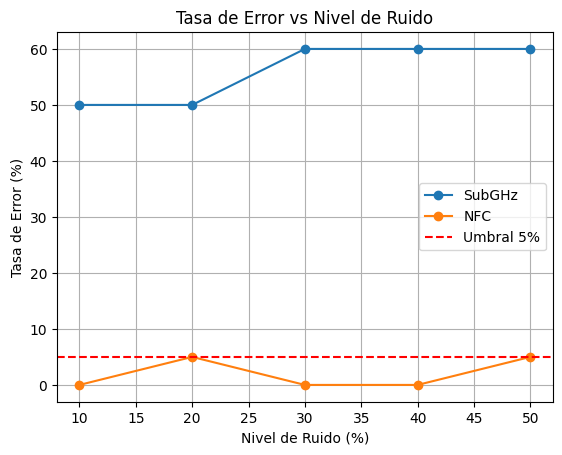

In [9]:
import matplotlib.pyplot as plt

noise_levels = [10, 20, 30, 40, 50]
subghz_errors = [50.00, 50.00, 60.00, 60.00, 60.00]
nfc_errors = [0.00, 5.00, 0.00, 0.00, 5.00]

plt.plot(noise_levels, subghz_errors, label="SubGHz", marker='o')
plt.plot(noise_levels, nfc_errors, label="NFC", marker='o')
plt.axhline(y=5, color='r', linestyle='--', label='Umbral 5%')
plt.xlabel("Nivel de Ruido (%)")
plt.ylabel("Tasa de Error (%)")
plt.title("Tasa de Error vs Nivel de Ruido")
plt.legend()
plt.grid(True)
plt.show()